URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 2.3. Signal review

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p2/stats/](https://zzz.bwh.harvard.edu/luna-walkthrough/p2/stats/)

In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../harm1.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x103b22f30> 

read 20 individuals from ../harm1.lst


Next, we'll calculate some summary statistics for the EEG, at this stage only for the purpose of general QC:

 - do the signals have numerical distributions/ranges broadly as expected for micro-volt scaled human scalp sleep EEG (i.e. on the order of 10s to 100s of units around a mean typically near zero)?

 - are there obvious parts of the recording (signals and/or epochs) that appear aberrant?

 - as a first-pass frequency-based description of the data, do we roughly see the expected 1/f pattern for the EEG power spectra? Are there many obvious spikes or other signs of contamination, e.g. due to electrical noise?

We'll approach this in two stages: first, with some whole-night visualizations based on Hjorth parameters; second, looking only at epochs annotated as N2 sleep (i.e. to remove the often very large sources of variation in signals that arise from stage differences, especially if noisy leading/trailing wake epochs are included).

In [2]:
# import some utility functions we'll use below
import sys
sys.path.append('../')
from helperfuncs import heatmap, safe_to_numeric

## Whole-night Hjorth statistics

This will take a minute or two to run:

In [8]:
# luna harm1.lst -o out.db -s ' SIGSTATS epoch sig=${eeg} '
res = proj.silent_proc( 'SIGSTATS epoch sig=${eeg}' )

In [9]:
# destrat out.db +SIGSTATS -r E CH   > tmp/hjorth.1
tbl = proj.table( 'SIGSTATS' , 'CH_E' )

In [10]:
tbl = safe_to_numeric( tbl ) 

To visualize the output, we'll use `matplotlib`, reproducing the same histograms as the original walk-through.

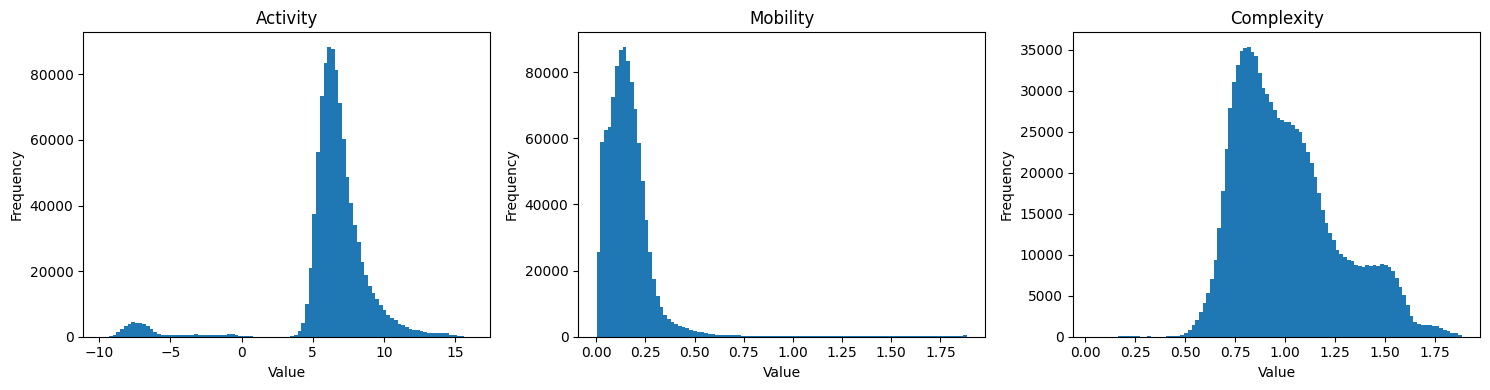

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

axes[0].hist(tbl.H1, bins=100 )
axes[1].hist(tbl.H2, bins=100 )
axes[2].hist(tbl.H3, bins=100 )

axes[0].set_title('Activity')
axes[1].set_title('Mobility')
axes[2].set_title('Complexity')

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()

Revising with log-scaled _activity_ values (and changing the values to numeric):

In [12]:
from numpy import log
tbl.H1 = log( tbl.H1 )

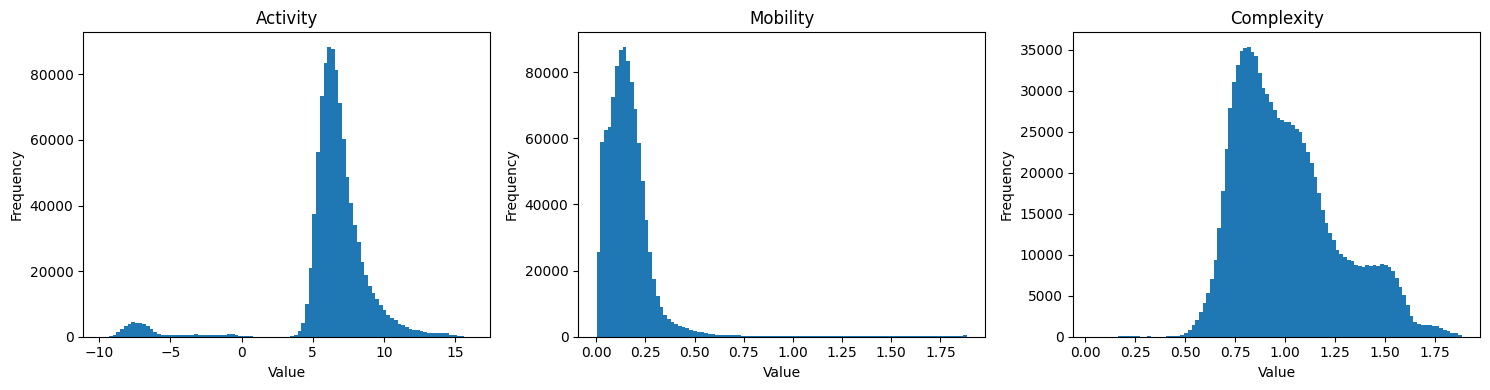

In [15]:
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

axes[0].hist(tbl.H1, bins=100 )
axes[1].hist(tbl.H2, bins=100 )
axes[2].hist(tbl.H3, bins=100 )

axes[0].set_title('Activity')
axes[1].set_title('Mobility')
axes[2].set_title('Complexity')

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()

We can review per individual:

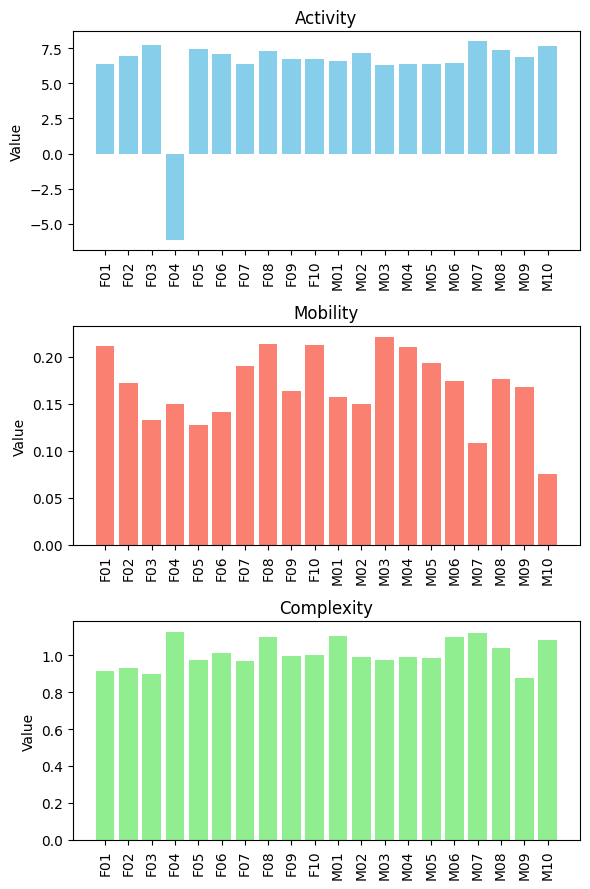

In [16]:
grps = tbl.groupby('ID')[[ 'H1', 'H2', 'H3' ]]
ids = grps.groups.keys()
vals = grps.mean()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 9))

axes[0].bar(ids, vals.H1, color='skyblue' )
axes[1].bar(ids, vals.H2, color='salmon' )
axes[2].bar(ids, vals.H3, color='lightgreen' )

axes[0].set_title('Activity')
axes[1].set_title('Mobility')
axes[2].set_title('Complexity')

for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Value')
    
plt.tight_layout()

With respect to `F04` - we can confirm visually that the lower activity values hold for all channels, e.g. here averaging over epochs:

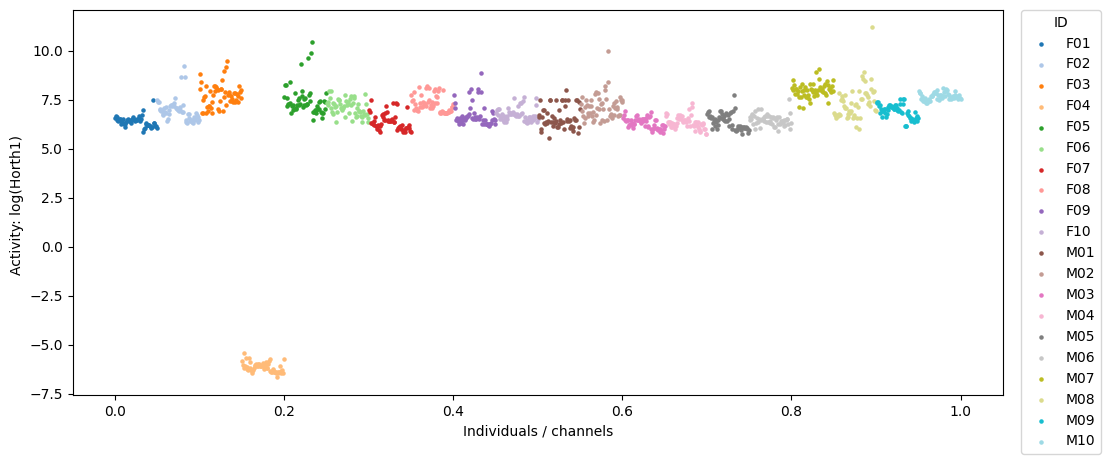

In [206]:
# a <- aggregate( d$H1 , by = list( CH = d$CH, ID = d$ID  ) , FUN = mean ) 
# plot(a$x, col=as.factor(a$ID), pch=20, ylab="mean H1", xlab="Indiv/channel" )

df = tbl.groupby(['ID', 'CH'])['H1'].mean().reset_index()

unique_ids = df.ID.unique()
colors = plt.cm.tab20(range(len(unique_ids)))  # Choose a color palette
color_map = dict(zip(unique_ids, colors))
df['X'] = np.linspace(0, 1, len(df.H1) )

plt.figure(figsize=(12, 5))  # (width, height) in inches
for uid in unique_ids:
    subset = df[df['ID'] == uid]
    plt.scatter( subset.X , subset.H1,  label=uid, color=color_map[uid], s=5)

# Add legend and labels
plt.xlabel('Individuals / channels')
plt.ylabel('Activity: log(Horth1) ')
plt.legend(title='ID', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

Alternatively, we can look at the headers to get the physical min/max, e.g. just for one channel.

In [114]:
# luna harm1.lst -o out.db -s HEADERS
res = proj.silent_proc( 'HEADERS sig=Fz' ) 

In [115]:
# destrat out.db +HEADERS -r CH/FZ -v PDIM PMIN PMAX 
proj.table( 'HEADERS' , 'CH' )[ [ 'ID', 'PDIM', 'PMIN', 'PMAX' ] ] 

,ID,PDIM,PMIN,PMAX
0,F01,uV,-361.057,223.325
1,F02,uV,-1694.12,1654.7
2,F03,uV,-466.484,1221.58
3,F04,uV,-2.97696,2.00623
4,F05,uV,-452.115,376.299
5,F06,uV,-1607.19,3502.42
6,F07,uV,-799.459,994.355
7,F08,uV,-3002.94,3663.41
8,F09,uV,-4028.45,1704.35
9,F10,uV,-2111.8,1747.34


The range appears to be about three orders-of-magnitude smaller for `F04` than for all other recordings, despite all channels having nominally similar units (uV). There is quite a lot of variability in the ranges (from ~200 to ~4000) but it is noteworthy that if multiplied by 1000 (i.e. the scaling difference between milli-volts and micro-volts, then `F04` would sit about right in the middle of all individuals, in terms of EDF header physical min/max for this channel.

It is also worth noting, however, that EDF headers can have extreme values (e.g. 4000 uV) because they contain artifact, in the signal. etc. Therefore, to more realistically compare distributions, it can be useful to a) restrict to parts of the signal scored as sleep if available (i.e. less artifact, movement, etc) and b) look at e.g. 5/95th percentile values rather than absolute (theoretical) min/max values. We can do this with the `STATS` command (here just for FZ for simplicity):

In [3]:
# luna harm1.lst -o out.db -s 'MASK ifnot=N2 & RE & STATS sig=FZ '
res = proj.silent_proc( 'MASK ifnot=N2 & RE & STATS sig=FZ' ) 

In [7]:
# destrat out.db +STATS -r CH -v P05 P95 -p 4 
proj.table( 'STATS', 'CH' )[ [ 'ID', 'P05', 'P95' ] ] 

,ID,P05,P95
0,F01,-13.089015,75.748559
1,F02,-45.08101,94.676718
2,F03,-36.450759,96.796439
3,F04,-0.165813,0.260612
4,F05,-49.661818,101.712722
5,F06,-36.531673,94.843819
6,F07,-76.212684,13.758577
7,F08,-35.302937,94.901198
8,F09,-78.604598,19.019645
9,F10,-18.848846,81.435207


As before, we see these are still orders-of-magnitude lower than for the other individuals: as we're _blessed with omniscience_ for certain aspects of this walkthrough, we in fact know that `F04` had altered signal units, i.e. it was actually recorded in milli-volts (mV) but incorrectly labelled as micro-volts (uV) which are 1000-times smaller. 

---

As the sleep EEG contains qualitatively distinct stages, whole-night summaries of metrics have limited value: we really want to see how things change, as well as channel-specific variation. To this end, we'll generate a series of plots that reflect the Hjorth statistics varying over time (epochs) and channel, which should still be stored in `tbl`:


In [17]:
tbl

,ID,CH,E,H1,H2,H3
0,F01,AF3,1,12.681152,0.022675,1.324543
1,F02,AF3,1,8.303459,0.243853,1.370869
2,F03,AF3,1,11.881204,0.091162,1.574155
3,F04,AF3,1,-6.979800,0.166664,1.296263
4,F05,AF3,1,9.017023,0.057312,1.220481
...,...,...,...,...,...,...
1024702,M07,TP8,994,7.205839,0.064664,1.079185
1024703,M07,TP8,995,7.406935,0.058568,1.103767
1024704,M07,TP8,996,7.012956,0.065526,1.143173
1024705,M07,TP8,997,6.253985,0.108572,1.080250


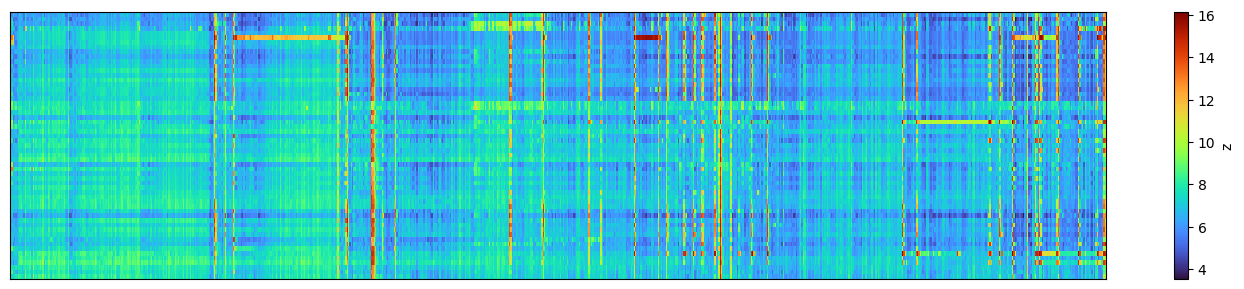

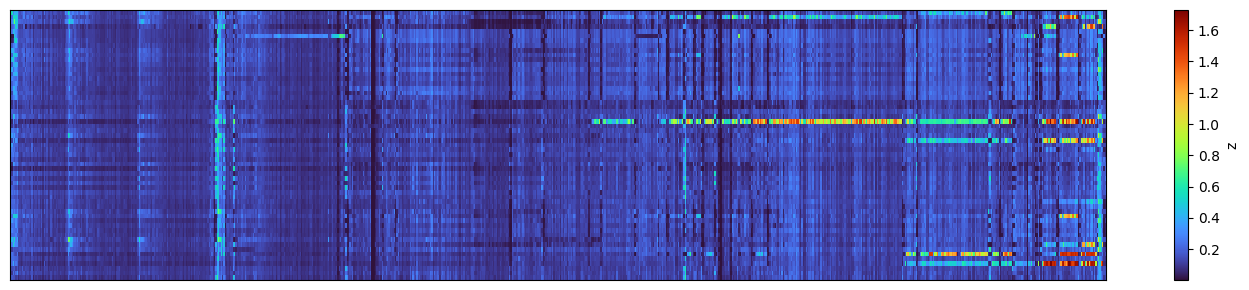

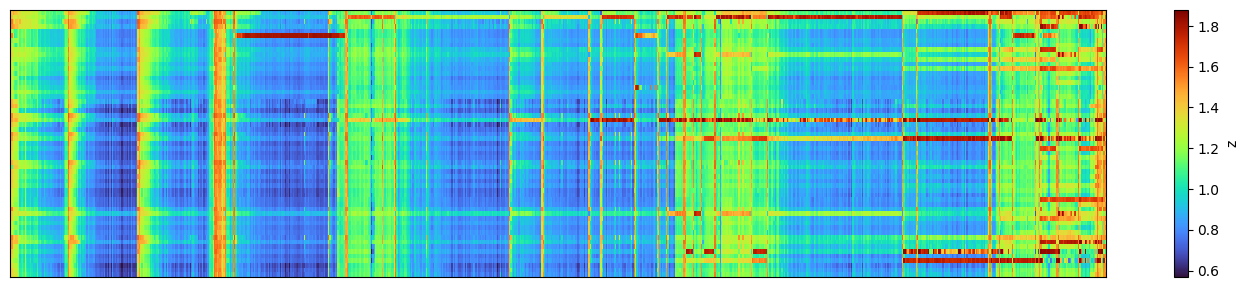

In [18]:
# look at F06 only
df = tbl[ tbl.ID == 'F06' ] 
heatmap( df.E , df.CH , df.H1 )
heatmap( df.E , df.CH , df.H2 )
heatmap( df.E , df.CH , df.H3 )

## N2 statistics

As a complement to the whole-night QC visualization, it can also be useful to restrict it to a single stage (or at least exclude leading/trailing wake/unknown periods if they are excessively long). In this way, differences between individuals and/or channels can become clearer, after removing one natural source of variation (differences in sleep stage).

To this end, we'll pick 10 N2 epochs at random.  However, keep in mind, that we do this just to speed up analysis in the context of this walkthrough. Naturally, for real projects, you'd want to use all available data. This script also applies a bandpass filter before calculating spectral statistics per individual/channel.

In [28]:
# luna harm1.lst -o out.db \
#  -s ' EPOCH align & MASK ifnot=N2 & MASK random=10 & RE
#       FILTER bandpass=0.3,35 tw=0.5,5 ripple=0.01,0.01
#       PSD spectrum dB sig=${eeg} max=25 '

res = proj.silent_proc( """ EPOCH align & MASK ifnot=N2 & MASK random=10 & RE
                            FILTER bandpass=0.3,35 tw=0.5,5 ripple=0.01,0.01
                            PSD spectrum dB sig=${eeg} max=25 """ )

Extracting the N2 power spectra:

In [35]:
# destrat out.db +PSD -r F CH > tmp/s.spec
tbl = proj.table( 'PSD' , 'CH_F' ).sort_values( [ 'ID', 'CH', 'F' ] ) 
tbl = safe_to_numeric( tbl )
# get mean per individual (average over channels) 
#tbl[[ 'F', 'PSD' ]] = tbl[['F', 'PSD' ]].apply(pd.to_numeric, errors='coerce')
df = tbl.groupby( [ 'ID', 'F' ] ).mean(numeric_only=True).reset_index()
df

,ID,F,PSD
0,F01,0.50,20.398297
1,F01,0.75,20.290623
2,F01,1.00,18.471769
3,F01,1.25,17.269133
4,F01,1.50,15.861061
...,...,...,...
1975,M10,24.00,-11.098668
1976,M10,24.25,-11.031471
1977,M10,24.50,-11.467396
1978,M10,24.75,-11.626988


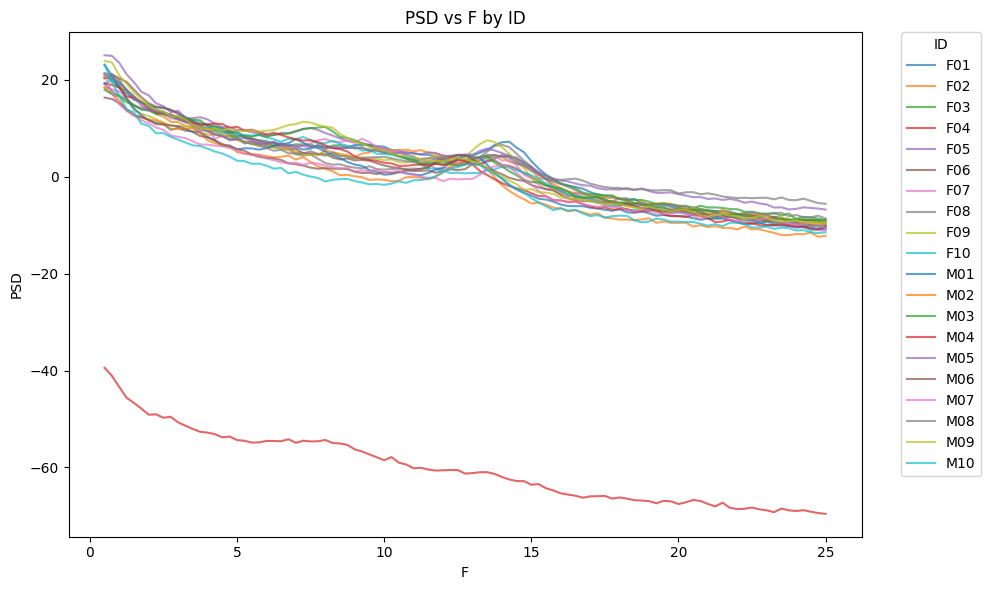

In [36]:
# plot (one line == one individual) 
plt.figure(figsize=(10, 6))
for uid, group in df.groupby('ID'):
    plt.plot(group['F'], group['PSD'], label=uid, alpha=0.7)
plt.xlabel('F')
plt.ylabel('PSD')
plt.title('PSD vs F by ID')
plt.legend(title='ID', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

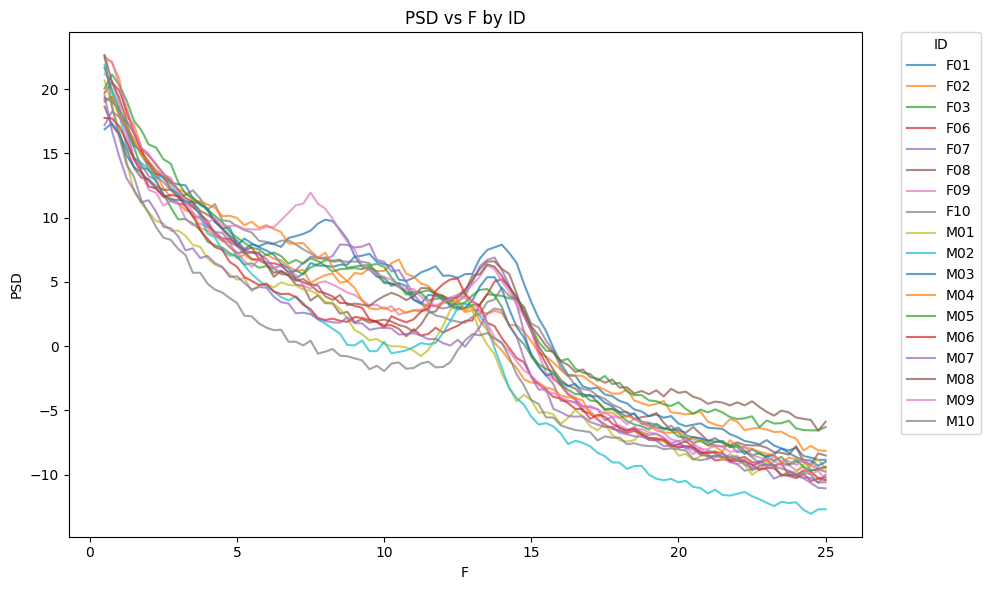

In [177]:
# with outliers (F04 and F05) removed
df = tbl[ ~tbl.ID.isin( [ 'F04' , 'F05' ] ) ] 
df = df.groupby( [ 'ID', 'F' ] ).mean(numeric_only=True).reset_index()
plt.figure(figsize=(10, 6))
for uid, group in df.groupby('ID'):
    plt.plot(group['F'], group['PSD'], label=uid, alpha=0.7)
plt.xlabel('F')
plt.ylabel('PSD')
plt.title('PSD vs F by ID')
plt.legend(title='ID', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

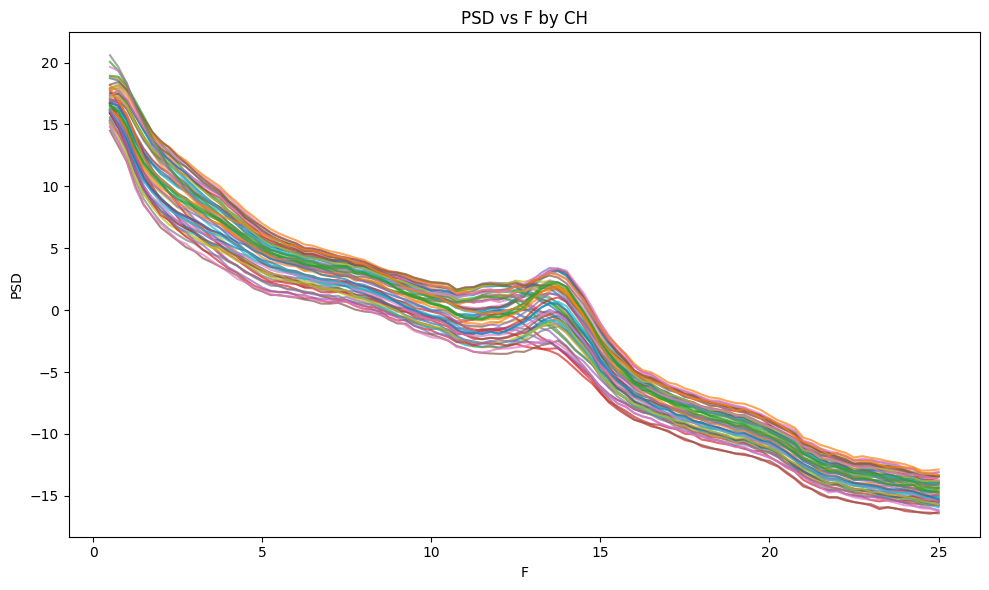

In [156]:
# repeat, but by channel:
df = tbl.groupby( [ 'CH', 'F' ] ).mean(numeric_only=True).reset_index()
plt.figure(figsize=(10, 6))
for uid, group in df.groupby('ID'):
    plt.plot(group['F'], group['PSD'], label=uid, alpha=0.7)
plt.xlabel('F')
plt.ylabel('PSD')
plt.title('PSD vs F by CH')
plt.legend(title='ID', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

In [179]:
# finally, a 5x5 grid of all PSD
tbl = proj.table( 'PSD' , 'CH_F' ).sort_values( [ 'ID', 'CH', 'F' ] ) 

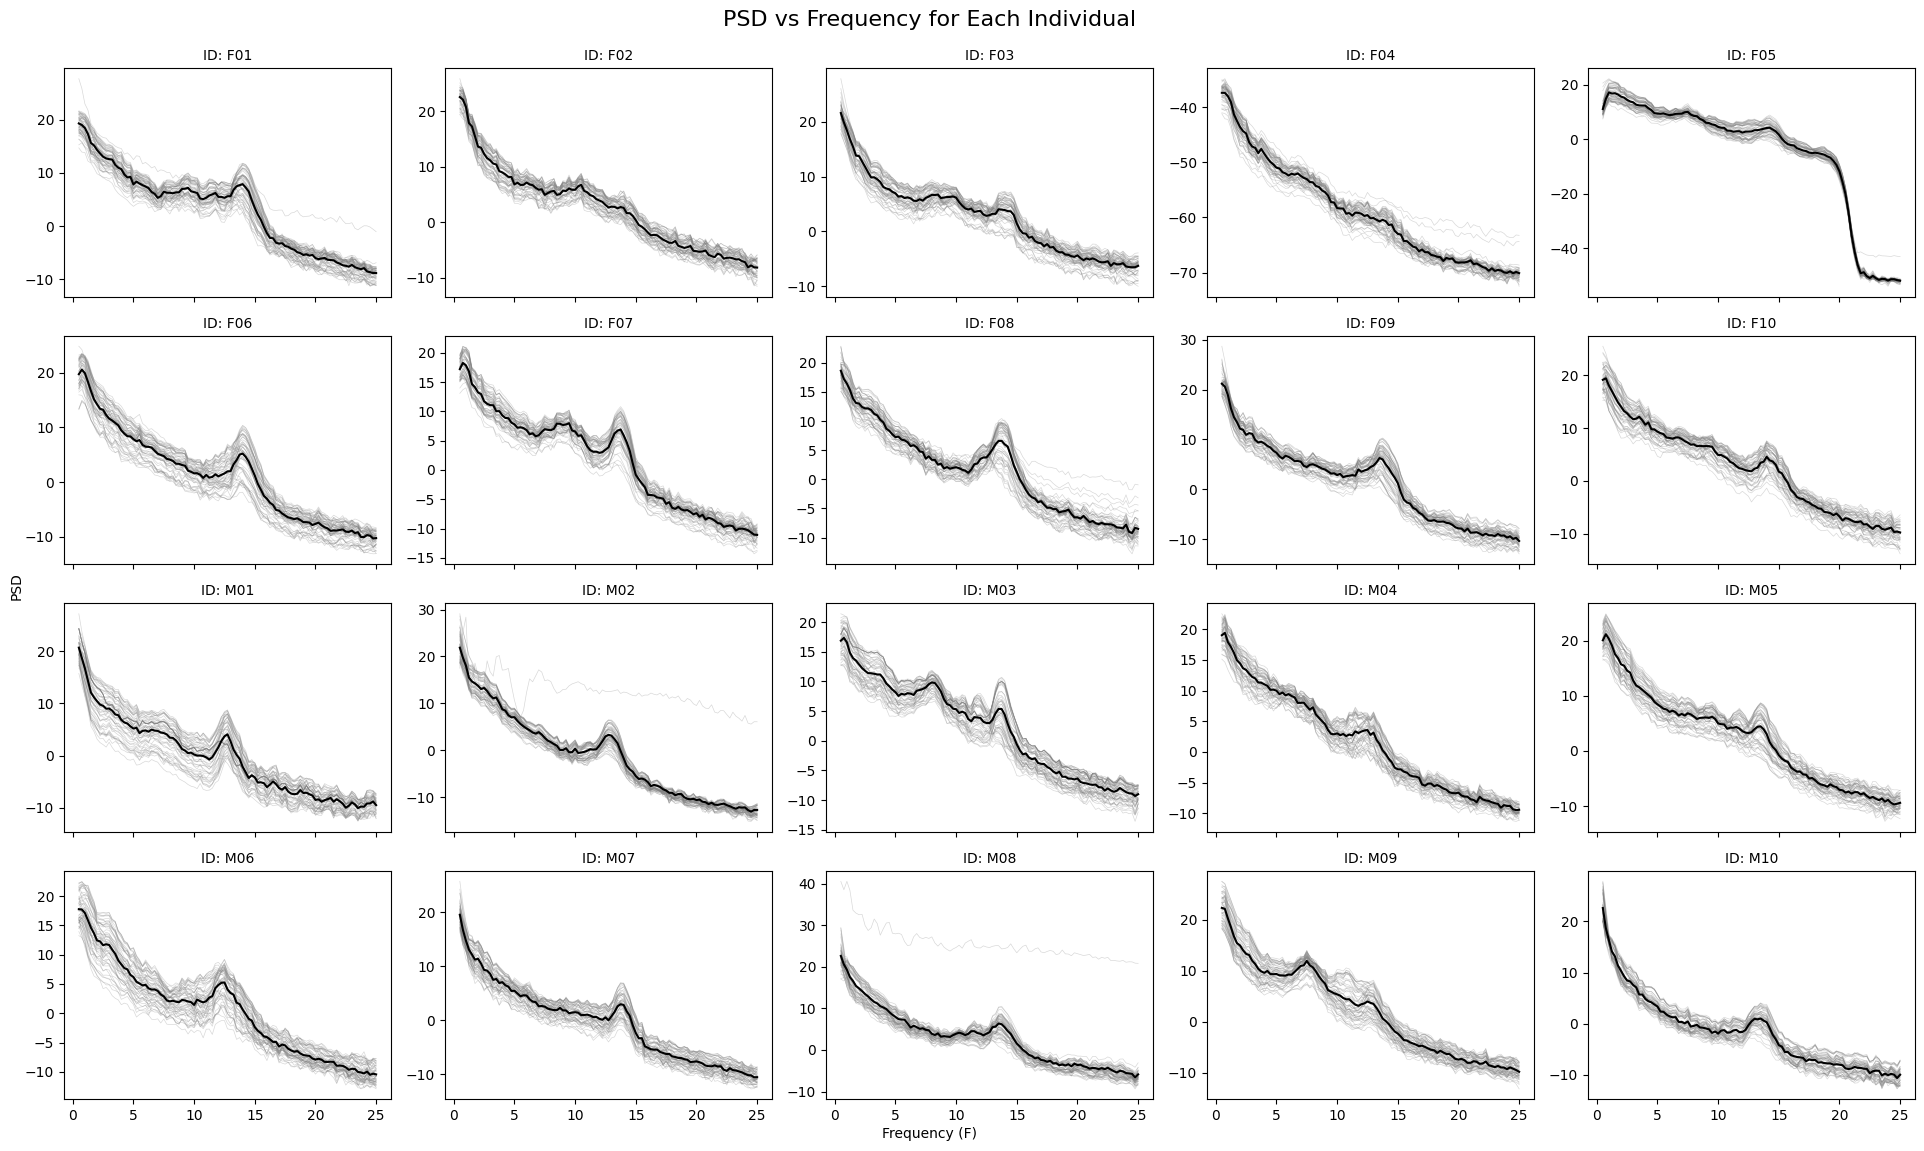

In [182]:
df = tbl 

unique_ids = sorted(df['ID'].unique())

# Set up 5x4 subplot grid
fig, axes = plt.subplots(4, 5, figsize=(20, 12), sharex=True, sharey=False)
axes = axes.flatten()  # Flatten to index as 1D

# Plot for each ID (one subplot per individual)
for i, uid in enumerate(unique_ids[:20]):  # Limit to 20 IDs
    ax = axes[i]
    subset = df[df['ID'] == uid]

    # Plot each channel line
    for ch, group in subset.groupby('CH'):
        ax.plot(group['F'], group['PSD'], color='gray', alpha=0.3, linewidth=0.5)

    # Plot mean across channels
    mean_psd = subset.groupby('F')['PSD'].mean()
    ax.plot(mean_psd.index, mean_psd.values, color='black', linewidth=1.5, label='Mean')

    ax.set_title(f'ID: {uid}', fontsize=10)

# Set common labels
fig.text(0.5, 0.04, 'Frequency (F)', ha='center')
fig.text(0.04, 0.5, 'PSD', va='center', rotation='vertical')
plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])
plt.suptitle("PSD vs Frequency for Each Individual", fontsize=16)

plt.show()

Having reviewed these EEG signals we've concluded the following:

 - `F04` appears to have incorrect units (uV but should be mV) for raw scalp EEG, relative to the other 19 individuals

 - based on epoch-wise, channel-specific Hjorth statistics, we've generated plots that indicate the likely presence of line-noise or other types of extreme artifact

 - focusing on N2 power spectra, we see the typical 1/f slope for the log-scaled PSD curves as well as evidence of peaks around sigma range, indicative of (true) physiological spindle activity

 - when looking person-by-person at the power spectra, some individuals appear to have spectral peaks at other modes (when averaging over all channels); we'll return to these details later, although for now we'll note that we have yet to confirm the accuracy/correctness of sleep staging annotations, which could naturally impact the interpretation of these plots

---

Next, we'll look at [EEG polarity](04_pol.ipynb) to scan for potentially flipped signals. 